In [ ]:
# =====================================================================
# THAILAND METEOROLOGICAL-STATION MAP — GOOGLE COLAB
#
# This notebook maps the stations extracted from the supplied station list.
# By default it plots currently open rows (Closed == "----") and removes
# exact duplicate physical points if any occur.
#
# OUTPUTS:
#   Thailand_met_stations_active.csv
#   Saraburi_nearby_met_stations.csv
#   Fig_Thailand_meteorological_station_network.png
#   Fig_Thailand_meteorological_station_network.pdf
# =====================================================================

# CELL 1 — INSTALL
!pip -q install geopandas openpyxl

Stations in supplied table : 150
Stations mapped            : 140
Active-only setting        : True

Nearest meteorological stations to Saraburi:
  WMO ICAO                               Name  latitude  longitude  distance_to_saraburi_km
48415 ----                          Ayutthaya   14.5344   100.7247                     20.0
48414 ----                       Nakhon Nayok   14.2719   101.1942                     41.9
48426 ----                           Lop Buri   14.7994   100.6281                     42.6
48435 ----                   Pakchong Agromet   14.6417   101.3214                     46.0
48419 ----                        Pathumthani   14.1158   100.6206                     55.5
48430 VTBI                       Prachin Buri   14.0506   101.3692                     72.6
48456 VTBD                          Don Muang   13.9189   100.6050                     75.2
48425 ----                        Suphan Buri   14.4742   100.1389                     83.3
48418 ----                

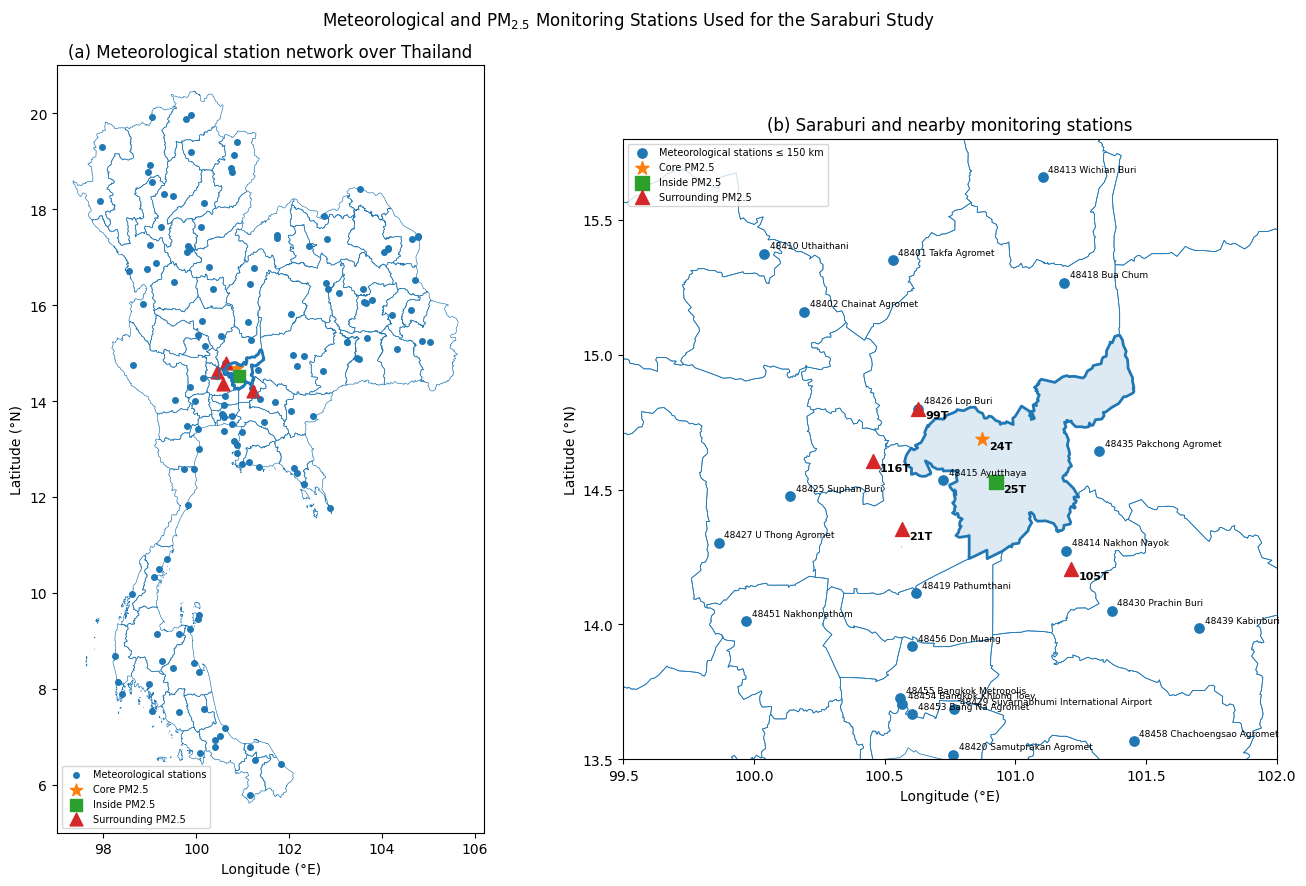


Saved:
/content/thailand_station_map/Fig_Thailand_meteorological_station_network.png
/content/thailand_station_map/Fig_Thailand_meteorological_station_network.pdf


In [ ]:


# CELL 2 — IMPORTS + CONFIG
import io
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import requests

from shapely.geometry import Point

OUT_DIR = "/content/thailand_station_map"
os.makedirs(OUT_DIR, exist_ok=True)

ACTIVE_ONLY = True

# Radius used only for highlighting/labeling weather stations near Saraburi.
NEAR_SARABURI_KM = 150

# Approximate center used only for distance ranking and zooming.
SARABURI_CENTER_LAT = 14.53
SARABURI_CENTER_LON = 100.91

FIG_DPI = 300

# Optional PM2.5 monitoring-network overlay from the Saraburi study.
OVERLAY_PM25 = True

PM25_STATIONS = pd.DataFrame([
    {"stationID":"24T","name":"Na Phralan","role":"Core PM2.5","lat":14.6858,"lon":100.8720},
    {"stationID":"25T","name":"Saraburi city","role":"Inside PM2.5","lat":14.5263,"lon":100.9260},
    {"stationID":"99T","name":"Lop Buri","role":"Surrounding PM2.5","lat":14.8000,"lon":100.6285},
    {"stationID":"116T","name":"Ang Thong","role":"Surrounding PM2.5","lat":14.6063,"lon":100.4536},
    {"stationID":"105T","name":"Nakhon Nayok","role":"Surrounding PM2.5","lat":14.2042,"lon":101.2151},
    {"stationID":"21T","name":"Ayutthaya","role":"Surrounding PM2.5","lat":14.3522,"lon":100.5653},
])

# CELL 3 — EMBEDDED STATION DATA
STATION_CSV = r"""WIGOS,WMO,ICAO,Name,Country,latitude,longitude,Altitude_m,Established,Closed,active
0-0-0-MISSING,-----,VTBO,Trat Airport,Thailand,12.274722222222223,102.31888888888888,32,----,----,True
0-0-0-MISSING,-----,VTPO,Sukhothai Airport,Thailand,17.238055555555558,99.81805555555555,55,----,----,True
0-0-0-MISSING,-----,VTSE,Chumphon Airport,Thailand,10.71111111111111,99.36166666666666,6,----,----,True
0-0-0-MISSING,-----,VTSM,Samui Airport,Thailand,9.547777777777778,100.06222222222222,20,----,----,True
0-0-0-MISSING,-----,VTSY,Yala / Betong Airport,Thailand,5.791666666666667,101.15277777777779,230,----,----,True
0-0-0-MISSING,-----,VTUI,Sakon Nakhon Airport,Thailand,17.195,104.11888888888888,161,----,----,True
0-0-0-MISSING,-----,VTUO,Buri Ram Airport,Thailand,15.229444444444445,103.25333333333333,184,----,----,True
0-0-0-MISSING,-----,VTUQ,Nakhon Ratchasima Airport,Thailand,14.949444444444445,102.31277777777777,233,----,----,True
0-0-0-MISSING,-----,VTUV,Roi Et,Thailand,16.116666666666667,103.77388888888889,138,----,----,True
0-0-0-MISSING,-----,VTUW,Nakhon Phanom West,Thailand,17.383888888888887,104.64305555555556,179,----,----,True
0-20000-0-48300,48300,VTCH,Mae Hong Son,Thailand,19.29888888888889,97.97555555555556,265,2014-11-01,----,True
0-0-0-MISSING,48300,VTCH,Mae Hong Son,Thailand,19.29888888888889,97.97555555555556,265,1951-01-01,2014-11-01,False
0-20000-0-48302,48302,----,Doi Ang Khang,Thailand,19.93277777777778,99.04527777777777,1529,1960-01-01,----,True
0-20000-0-48303,48303,VTCT,Chiang Rai,Thailand,19.961388888888887,99.88083333333333,390,1951-01-01,----,True
0-20000-0-48304,48304,----,Chaing Rai Agromet,Thailand,19.872222222222224,99.77916666666667,397,1978-12-01,----,True
0-20000-0-48307,48307,----,Tung Chang,Thailand,19.408055555555553,100.88194444444444,333,2001-01-01,----,True
0-20000-0-48310,48310,----,Phayao,Thailand,19.193055555555556,99.88333333333334,397,1982-01-01,----,True
0-20000-0-48315,48315,----,Tha Wang Pha,Thailand,19.123055555555556,100.81305555555555,235,1987-01-01,----,True
0-20000-0-48324,48324,----,Thoen,Thailand,17.636388888888888,99.24444444444444,191,2003-01-01,----,True
0-20000-0-48325,48325,VTCS,Mae Sariang,Thailand,18.175,97.93333333333334,212,1952-01-01,----,True
0-0-0-MISSING,48326,----,Mae Jo Agromet,Thailand,18.916666666666668,99.0,317,----,----,True
0-20000-0-48327,48327,VTCC,Chiang Mai,Thailand,18.770555555555553,98.96805555555555,313,1911-01-01,----,True
0-20000-0-48328,48328,VTCL,Lampang,Thailand,18.278055555555554,99.50638888888889,242,1951-01-01,----,True
0-20000-0-48329,48329,----,Lamphun,Thailand,18.56638888888889,99.03805555555556,296,2014-11-01,----,True
0-0-0-MISSING,48329,----,Lamphun,Thailand,18.56638888888889,99.03805555555556,296,1982-01-01,2014-11-01,False
0-20000-0-48330,48330,VTCP,Phrae,Thailand,18.128055555555555,100.16194444444444,162,1952-01-01,----,True
0-20000-0-48331,48331,VTCN,Nan,Thailand,18.766666666666666,100.76305555555555,200,1951-01-01,----,True
0-20000-0-48333,48333,----,Nan Agromet,Thailand,18.863333333333333,100.74166666666667,264,1983-09-01,----,True
0-20000-0-48334,48334,----,Lampang Agromet,Thailand,18.32472222222222,99.30138888888888,315,1981-06-24,----,True
0-20000-0-48350,48350,----,Loei Agromet,Thailand,17.409166666666664,101.72916666666667,260,1970-05-01,----,True
0-20000-0-48351,48351,VTPU,Uttaradit,Thailand,17.624166666666667,100.09666666666666,63,1951-01-01,----,True
0-20000-0-48352,48352,VTUM,Nong Khai,Thailand,17.864722222222223,102.74694444444445,174,1977-01-01,----,True
0-20000-0-48353,48353,VTUL,Loei,Thailand,17.4525,101.73055555555555,253,1954-01-01,----,True
0-20000-0-48354,48354,VTUD,Udon Thani,Thailand,17.37666666666667,102.80916666666667,177,1949-01-01,----,True
0-20000-0-48355,48355,----,Sakon Nakhon Agromet,Thailand,17.116666666666667,104.04972222222221,190,1966-09-16,----,True
0-20000-0-48356,48356,VTUS,Sakon Nakhon,Thailand,17.160277777777775,104.13305555555554,171,1952-01-01,----,True
0-20000-0-48357,48357,VTUP,Nakhon Phanom,Thailand,17.416666666666668,104.78305555555555,145,1952-01-01,----,True
0-20000-0-48358,48358,----,Nakhon Phanom Agromet,Thailand,17.43305555555556,104.78305555555555,153,1983-04-02,----,True
0-20000-0-48360,48360,----,Nongbualamphu,Thailand,17.231944444444444,102.42916666666667,227,2009-01-01,----,True
0-764-0-48363,48363,----,Buengkarn,Thailand,18.41333333333333,103.51666666666667,160,2020-01-29,----,True
0-20000-0-48372,48372,----,Sukhothai,Thailand,17.10666666666667,99.80027777777778,48,2001-01-01,----,True
0-20000-0-48373,48373,----,Si Samrong Agromet,Thailand,17.160833333333333,99.86166666666666,53,1965-05-01,----,True
0-20000-0-48374,48374,----,Lomsak,Thailand,16.773888888888887,101.245,143,----,----,True
0-20000-0-48375,48375,VTPM,Mae Sot,Thailand,16.7025,98.54166666666667,196,1951-01-01,----,True
0-20000-0-48376,48376,VTPT,Tak,Thailand,16.879444444444445,99.14,124,1954-01-01,----,True
0-20000-0-48377,48377,----,Bhumibol Dam,Thailand,17.24388888888889,99.00222222222222,144,1960-01-01,----,True
0-20000-0-48378,48378,VTPP,Phitsanulok,Thailand,16.795833333333334,100.27555555555556,44,1949-01-01,----,True
0-20000-0-48379,48379,VTPB,Phetchabun,Thailand,16.434444444444445,101.15166666666667,114,1952-01-01,----,True
0-20000-0-48380,48380,----,Kam Paeng Phet,Thailand,16.486666666666668,99.52666666666667,80,----,----,True
0-20000-0-48381,48381,VTUK,Khon Kaen,Thailand,16.460555555555555,102.78916666666666,187,1951-01-01,----,True
0-20000-0-48382,48382,----,Kosumphisai,Thailand,16.24527777777778,103.06916666666666,153,----,----,True
0-20000-0-48383,48383,VTUB,Mukdahan,Thailand,16.533055555555556,104.71666666666667,138,1951-01-01,----,True
0-20000-0-48384,48384,----,Tha Phra Agromet,Thailand,16.335277777777776,102.82666666666667,166,1966-09-16,----,True
0-20000-0-48385,48385,----,Umphang,Thailand,16.025277777777777,98.85972222222222,454,2001-01-01,----,True
0-20000-0-48386,48386,----,Pichit Agromet,Thailand,16.33833333333333,100.36666666666666,35,2014-11-01,----,True
0-0-0-MISSING,48386,----,Pichit Agromet,Thailand,16.33833333333333,100.36666666666666,35,----,2014-11-01,False
0-20000-0-48387,48387,----,Doi Mu Soe Agromet,Thailand,16.751944444444444,98.93555555555555,863,1991-10-01,----,True
0-20000-0-48390,48390,----,Kamalasai,Thailand,16.331666666666667,103.58749999999999,139,2001-01-01,----,True
0-764-0-48391,48391,----,Amnart Jaroen,Thailand,15.902222222222223,104.61749999999999,180,2020-01-02,----,True
0-20000-0-48400,48400,VTPN,Nakhon Sawan,Thailand,15.671666666666667,100.13194444444444,34,2014-11-01,----,True
0-0-0-MISSING,48400,VTPN,Nakhon Sawan,Thailand,15.671666666666667,100.13194444444444,34,1949-01-01,2014-11-01,False
0-20000-0-48401,48401,----,Takfa Agromet,Thailand,15.349166666666667,100.53027777777778,91,1966-07-01,----,True
0-20000-0-48402,48402,----,Chainat Agromet,Thailand,15.158055555555556,100.1913888888889,15,----,----,True
0-20000-0-48403,48403,VTUC,Chaiyaphum,Thailand,15.811666666666667,102.02916666666667,182,1956-01-01,----,True
0-20000-0-48404,48404,----,Roi Et Agromet,Thailand,16.073055555555555,103.60805555555555,153,1983-04-21,----,True
0-20000-0-48405,48405,VTUR,Roi Et,Thailand,16.051666666666666,103.66416666666667,140,1951-01-01,----,True
0-764-0-48406,48406,----,Yasothon,Thailand,15.794722222222221,104.21416666666667,142,2020-01-02,----,True
0-20000-0-48407,48407,VTUU,Ubon Ratchathani,Thailand,15.25,104.86666666666666,122,1911-01-01,----,True
0-20000-0-48408,48408,----,Ubon Ratchathani Agromet,Thailand,15.233055555555556,105.03305555555555,130,2014-11-01,----,True
0-0-0-MISSING,48408,----,Ubon Ratchathani Agromet,Thailand,15.233055555555556,105.03305555555555,130,1966-09-21,2014-11-01,False
0-20000-0-48409,48409,----,Sisaket Agromet,Thailand,15.085277777777778,104.33055555555555,127,----,----,True
0-20000-0-48410,48410,----,Uthaithani,Thailand,15.374166666666667,100.03888888888889,24,----,----,True
0-20000-0-48413,48413,----,Wichian Buri,Thailand,15.656666666666666,101.10527777777777,68,1986-01-01,----,True
0-764-0-48414,48414,----,Nakhon Nayok,Thailand,14.271944444444445,101.19416666666667,24,2026-07-01,----,True
0-20000-0-48415,48415,----,Ayutthaya,Thailand,14.534444444444444,100.72472222222223,8,----,----,True
0-20000-0-48416,48416,----,Tha Tum,Thailand,15.315833333333334,103.68027777777779,128,1966-01-01,----,True
0-20000-0-48418,48418,----,Bua Chum,Thailand,15.266666666666667,101.18694444444445,49,1987-01-01,----,True
0-20000-0-48419,48419,----,Pathumthani,Thailand,14.115833333333333,100.62055555555555,6,----,----,True
0-20000-0-48420,48420,----,Samutprakan Agromet,Thailand,13.516666666666667,100.76166666666667,1,----,----,True
0-20000-0-48421,48421,----,Thong Pha Phum,Thailand,14.741944444444444,98.6363888888889,97,1987-01-01,----,True
0-20000-0-48425,48425,----,Suphan Buri,Thailand,14.474166666666667,100.1388888888889,7,1952-01-01,----,True
0-20000-0-48426,48426,----,Lop Buri,Thailand,14.799444444444445,100.62805555555555,10,1951-01-01,----,True
0-20000-0-48427,48427,----,U Thong Agromet,Thailand,14.303333333333335,99.86444444444444,6,1967-03-03,----,True
0-20000-0-48429,48429,----,Suvarnabhumi International Airport,Thailand,13.686388888888889,100.76722222222222,1,2016-04-28,----,True
0-20000-0-48430,48430,VTBI,Prachin Buri,Thailand,14.050555555555556,101.36916666666666,4,1951-01-01,----,True
0-20000-0-48431,48431,VTUN,Nakhon Ratchasima,Thailand,14.968055555555555,102.08555555555554,187,1949-01-01,----,True
0-20000-0-48432,48432,----,Surin,Thailand,14.873888888888889,103.49916666666667,146,1951-01-01,----,True
0-20000-0-48433,48433,----,Surin Agromet,Thailand,14.890555555555554,103.45194444444445,143,1966-10-01,----,True
0-20000-0-48434,48434,----,Chok Chai,Thailand,14.737777777777778,102.16805555555555,190,2001-01-01,----,True
0-20000-0-48435,48435,----,Pakchong Agromet,Thailand,14.641666666666666,101.32138888888889,386,1965-06-01,----,True
0-20000-0-48436,48436,----,Nang Rong,Thailand,14.630555555555556,102.72083333333333,179,2001-01-01,----,True
0-20000-0-48437,48437,----,Bureram,Thailand,15.234444444444444,103.25138888888888,182,----,----,True
0-20000-0-48438,48438,----,Samutsongkram,Thailand,13.407777777777778,100.03194444444445,2,----,----,True
0-20000-0-48439,48439,----,Kabinburi,Thailand,13.985555555555555,101.70416666666667,11,----,----,True
0-20000-0-48440,48440,----,Srakaew,Thailand,13.791666666666666,102.03194444444445,41,2001-01-01,----,True
0-20000-0-48450,48450,VTBG,Kanchanaburi,Thailand,14.0225,99.53555555555555,28,1911-01-01,----,True
0-20000-0-48451,48451,----,Nakhonpathom,Thailand,14.011666666666667,99.96972222222223,7,----,----,True
0-20000-0-48453,48453,----,Bang Na Agromet,Thailand,13.66638888888889,100.60583333333332,1,1966-10-01,----,True
0-20000-0-48454,48454,----,Bangkok Khlong Toey,Thailand,13.706666666666665,100.56805555555555,3,1951-01-01,----,True
0-20000-0-48455,48455,----,Bangkok Metropolis,Thailand,13.72638888888889,100.56,3,----,----,True
0-764-0-48456,48456,VTBD,Don Muang,Thailand,13.918888888888889,100.60499999999999,12,----,----,True
0-20000-0-48457,48457,----,Bangkok Pilot,Thailand,13.376944444444446,100.59916666666666,14,1960-01-01,----,True
0-20000-0-48458,48458,----,Chachoengsao Agromet,Thailand,13.566944444444443,101.45416666666667,69,----,----,True
0-20000-0-48459,48459,VTBS,Chon Buri,Thailand,13.355277777777777,100.98166666666667,1,1952-01-01,----,True
0-20000-0-48460,48460,----,Ko Sichang,Thailand,13.162222222222223,100.80222222222221,25,1958-08-11,----,True
0-20000-0-48461,48461,----,Phatthaya,Thailand,12.923055555555555,100.86527777777778,59,1982-01-01,----,True
0-20000-0-48462,48462,----,Aranyaprathet,Thailand,13.688333333333334,102.50416666666666,47,1951-01-01,----,True
0-20000-0-48463,48463,----,Laem Chabang,Thailand,13.077777777777778,100.87388888888889,81,2014-11-01,----,True
0-0-0-MISSING,48463,----,Laemchabang,Thailand,13.077777777777778,100.87388888888889,81,----,2014-11-01,False
0-20000-0-48464,48464,----,Ratcha Buri,Thailand,13.487499999999999,99.79555555555555,9,1992-01-01,----,True
0-20000-0-48465,48465,VTBJ,Phetchaburi,Thailand,12.999166666666666,100.06055555555555,2,2014-11-01,----,True
0-0-0-MISSING,48465,VTBJ,Phetchaburi,Thailand,12.999166666666666,100.06055555555555,2,1978-01-01,2014-11-01,False
0-20000-0-48474,48474,----,Nong Phlub Agromet,Thailand,12.58888888888889,99.73416666666667,106,1974-06-03,----,True
0-20000-0-48475,48475,VTPH,Hua Hin,Thailand,12.577777777777778,99.9538888888889,5,1951-01-01,----,True
0-20000-0-48477,48477,----,Sattahip,Thailand,12.69138888888889,100.98527777777778,16,1951-01-01,----,True
0-20000-0-48478,48478,VTBU,Rayong,Thailand,12.633333333333333,101.34055555555555,3,1982-01-01,----,True
0-20000-0-48479,48479,----,Huai Pong Agromet,Thailand,12.734444444444444,101.13527777777779,43,1965-05-01,----,True
0-20000-0-48480,48480,VTBC,Chanthaburi,Thailand,12.609166666666667,102.10388888888889,3,----,----,True
0-20000-0-48481,48481,----,Phliu Agromet,Thailand,12.510277777777778,102.16944444444445,22,1966-09-21,----,True
0-20000-0-48500,48500,VTBP,Prachuap Khirikhan,Thailand,11.835,99.81027777777777,4,1949-01-01,----,True
0-20000-0-48501,48501,----,Khlong Yai,Thailand,11.780277777777778,102.87805555555555,2,1952-01-01,----,True
0-20000-0-48517,48517,VTSD,Chumphon,Thailand,10.498333333333333,99.18805555555556,4,1949-01-01,----,True
0-20000-0-48520,48520,----,Sawi Agromet,Thailand,10.330555555555556,99.0925,13,1967-05-01,----,True
0-20000-0-48532,48532,VTSR,Ranong,Thailand,9.983055555555556,98.61666666666666,7,1951-01-01,----,True
0-20000-0-48550,48550,----,Ko Samui,Thailand,9.44888888888889,100.03666666666666,4,1977-01-01,----,True
0-20000-0-48551,48551,VTSB,Surat Thani,Thailand,9.134166666666665,99.15166666666667,5,2014-11-01,----,True
0-0-0-MISSING,48551,VTSB,Surat Thani,Thailand,9.134166666666665,99.15166666666667,5,1963-01-01,2014-11-01,False
0-20000-0-48552,48552,VTSF,Nakhonsi Thammarat,Thailand,8.544166666666667,99.94277777777778,4,1951-01-01,----,True
0-0-0-MISSING,48553,----,Khanom,Thailand,9.25,99.86666666666666,3,----,----,True
0-20000-0-48554,48554,----,Nakhonsi Thammarat Agromet,Thailand,8.359166666666667,100.05916666666667,2,2014-11-01,----,True
0-0-0-MISSING,48554,----,Nakhonsi Thammarat Agromet,Thailand,8.359166666666667,100.05916666666667,2,1983-09-01,2014-11-01,False
0-20000-0-48555,48555,----,Surat Thani Agromet,Thailand,9.142777777777777,99.63583333333334,35,1992-01-01,----,True
0-20000-0-48556,48556,----,Phrasang,Thailand,8.57,99.25805555555556,12,----,----,True
0-20000-0-48557,48557,----,Chawang,Thailand,8.424166666666666,99.50638888888889,28,2001-01-01,----,True
0-20000-0-48560,48560,----,Phatthalung Agromet,Thailand,7.580555555555556,100.16583333333334,2,----,----,True
0-20000-0-48561,48561,----,Takua Pa,Thailand,8.684166666666666,98.25194444444445,6,2014-11-01,----,True
0-0-0-MISSING,48561,----,Takua Pa,Thailand,8.684166666666666,98.25194444444445,6,1979-01-01,2014-11-01,False
0-20000-0-48563,48563,VTSG,Krabi,Thailand,8.103333333333333,98.97527777777778,29,1995-01-01,----,True
0-20000-0-48564,48564,----,Phuket,Thailand,7.883055555555556,98.4,2,1951-01-01,----,True
0-20000-0-48565,48565,VTSP,Phuket Airport,Thailand,8.14472222222222,98.31416666666667,6,1937-02-11,----,True
0-20000-0-48566,48566,----,Ko Lanta,Thailand,7.533055555555555,99.04972222222221,2,1981-05-15,----,True
0-20000-0-48567,48567,VTST,Trang,Thailand,7.516666666666667,99.61666666666666,14,1951-01-01,----,True
0-20000-0-48568,48568,VTSH,Songkhla,Thailand,7.181666666666667,100.60749999999999,5,1951-01-02,----,True
0-20000-0-48569,48569,VTSS,Hat Yai Airport,Thailand,6.9375,100.39527777777778,27,1972-07-15,----,True
0-20000-0-48570,48570,VTSA,Satun,Thailand,6.653333333333333,100.08305555555555,4,1978-01-01,----,True
0-20000-0-48571,48571,----,Kho Hong Agromet,Thailand,7.015555555555555,100.50166666666667,7,----,----,True
0-20000-0-48574,48574,----,Sa-Dao,Thailand,6.786944444444444,100.41277777777778,25,----,----,True
0-20000-0-48580,48580,VTSK,Pattani,Thailand,6.79,101.14666666666668,4,1964-08-11,----,True
0-20000-0-48581,48581,----,Yala Agromet,Thailand,6.5152777777777775,101.27305555555556,30,1981-07-01,----,True
0-20000-0-48583,48583,VTSC,Narathiwat,Thailand,6.426666666666667,101.825,4,1951-01-01,----,True
"""

stations = pd.read_csv(io.StringIO(STATION_CSV))

# Ensure proper numeric coordinates.
stations["latitude"] = pd.to_numeric(stations["latitude"], errors="coerce")
stations["longitude"] = pd.to_numeric(stations["longitude"], errors="coerce")

stations = stations.dropna(
    subset=["latitude", "longitude"]
).copy()

stations = stations[
    stations["Country"].astype(str).str.strip().str.lower().eq("thailand")
].copy()

# Convert embedded bool robustly.
stations["active"] = (
    stations["active"]
    .astype(str)
    .str.lower()
    .isin(["true", "1", "yes"])
)

if ACTIVE_ONLY:
    stations_plot = stations[
        stations["active"]
    ].copy()
else:
    stations_plot = stations.copy()

# Remove exact repeated physical points if present.
stations_plot = (
    stations_plot
    .sort_values(["Name", "WMO", "Established"])
    .drop_duplicates(
        subset=["Name", "latitude", "longitude"],
        keep="last"
    )
    .reset_index(drop=True)
)

print("Stations in supplied table :", len(stations))
print("Stations mapped            :", len(stations_plot))
print("Active-only setting        :", ACTIVE_ONLY)

# CELL 4 — THAILAND PROVINCE BOUNDARIES
PROV_URL = (
    "https://raw.githubusercontent.com/"
    "chingchai/OpenGISData-Thailand/"
    "master/provinces.geojson"
)

PROV_FILE = "/content/th_provinces.geojson"

if not os.path.exists(PROV_FILE):
    r = requests.get(PROV_URL, timeout=120)
    r.raise_for_status()

    with open(PROV_FILE, "wb") as f:
        f.write(r.content)

prov = gpd.read_file(PROV_FILE)

if prov.crs is None:
    prov = prov.set_crs(epsg=4326)

prov = prov.to_crs(epsg=4326)

# Detect English province-name field.
province_name_candidates = [
    "pro_en",
    "NAME_1",
    "name_en",
    "province_en",
]

province_name_field = None

for candidate in province_name_candidates:
    if candidate in prov.columns:
        province_name_field = candidate
        break

if province_name_field is None:
    raise RuntimeError(
        "Could not identify the English province-name field. "
        f"Columns = {list(prov.columns)}"
    )

prov["province_norm"] = (
    prov[province_name_field]
    .astype(str)
    .str.lower()
    .str.replace(" ", "", regex=False)
)

saraburi = prov[
    prov["province_norm"].isin(
        ["saraburi", "saraburiprovince"]
    )
].copy()

if saraburi.empty:
    raise RuntimeError("Saraburi province could not be found in boundary data.")

# CELL 5 — CREATE GEODATAFRAME + DISTANCE TO SARABURI
stations_gdf = gpd.GeoDataFrame(
    stations_plot,
    geometry=gpd.points_from_xy(
        stations_plot["longitude"],
        stations_plot["latitude"],
    ),
    crs="EPSG:4326",
)

# Use UTM 47N for metric distance.
stations_m = stations_gdf.to_crs("EPSG:32647")

saraburi_center = gpd.GeoSeries(
    [Point(SARABURI_CENTER_LON, SARABURI_CENTER_LAT)],
    crs="EPSG:4326",
).to_crs("EPSG:32647").iloc[0]

stations_gdf["distance_to_saraburi_km"] = (
    stations_m.geometry.distance(saraburi_center) / 1000.0
)

near_saraburi = (
    stations_gdf[
        stations_gdf["distance_to_saraburi_km"] <= NEAR_SARABURI_KM
    ]
    .sort_values("distance_to_saraburi_km")
    .copy()
)

stations_gdf.drop(columns="geometry").to_csv(
    os.path.join(OUT_DIR, "Thailand_met_stations_active.csv"),
    index=False,
    encoding="utf-8-sig",
)

near_saraburi.drop(columns="geometry").to_csv(
    os.path.join(OUT_DIR, "Saraburi_nearby_met_stations.csv"),
    index=False,
    encoding="utf-8-sig",
)

print("\nNearest meteorological stations to Saraburi:")
print(
    near_saraburi[
        [
            "WMO",
            "ICAO",
            "Name",
            "latitude",
            "longitude",
            "distance_to_saraburi_km",
        ]
    ]
    .head(20)
    .round({"latitude":4, "longitude":4, "distance_to_saraburi_km":1})
    .to_string(index=False)
)

# CELL 6 — PUBLICATION MAP: THAILAND + CENTRAL-THAILAND INSET
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 9),
)

# ---------------------------------------------------------------------
# (a) National network
# ---------------------------------------------------------------------
ax = axes[0]

prov.boundary.plot(
    ax=ax,
    linewidth=0.45,
)

stations_gdf.plot(
    ax=ax,
    markersize=16,
    marker="o",
    label="Meteorological stations",
)

saraburi.boundary.plot(
    ax=ax,
    linewidth=2.0,
)

# Optional PM2.5 overlay.
if OVERLAY_PM25:
    pm25_gdf = gpd.GeoDataFrame(
        PM25_STATIONS,
        geometry=gpd.points_from_xy(
            PM25_STATIONS["lon"],
            PM25_STATIONS["lat"],
        ),
        crs="EPSG:4326",
    )

    for role, marker in [
        ("Core PM2.5", "*"),
        ("Inside PM2.5", "s"),
        ("Surrounding PM2.5", "^"),
    ]:
        sub = pm25_gdf[
            pm25_gdf["role"] == role
        ]

        if not sub.empty:
            sub.plot(
                ax=ax,
                markersize=85,
                marker=marker,
                label=role,
            )

ax.set_xlim(97.0, 106.2)
ax.set_ylim(5.0, 21.0)

ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.set_title("(a) Meteorological station network over Thailand")
ax.legend(loc="lower left", fontsize=7)

# ---------------------------------------------------------------------
# (b) Central Thailand / Saraburi zoom
# ---------------------------------------------------------------------
ax = axes[1]

prov.boundary.plot(
    ax=ax,
    linewidth=0.55,
)

saraburi.plot(
    ax=ax,
    alpha=0.15,
)

saraburi.boundary.plot(
    ax=ax,
    linewidth=2.0,
)

near_saraburi.plot(
    ax=ax,
    markersize=45,
    marker="o",
    label=f"Meteorological stations ≤ {NEAR_SARABURI_KM} km",
)

# Label nearby meteorological stations using WMO + name.
for _, row in near_saraburi.iterrows():

    wmo = str(row["WMO"]).strip()

    if wmo in ["-----", "nan", "None"]:
        label = str(row["Name"])
    else:
        label = f"{wmo} {row['Name']}"

    ax.annotate(
        label,
        (row.geometry.x, row.geometry.y),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=6.5,
    )

if OVERLAY_PM25:

    for role, marker in [
        ("Core PM2.5", "*"),
        ("Inside PM2.5", "s"),
        ("Surrounding PM2.5", "^"),
    ]:

        sub = pm25_gdf[
            pm25_gdf["role"] == role
        ]

        if not sub.empty:
            sub.plot(
                ax=ax,
                markersize=100,
                marker=marker,
                label=role,
            )

    for _, row in pm25_gdf.iterrows():
        ax.annotate(
            row["stationID"],
            (row.geometry.x, row.geometry.y),
            xytext=(5, -7),
            textcoords="offset points",
            fontsize=8,
            fontweight="bold",
        )

# Central Thailand viewing window.
ax.set_xlim(99.5, 102.0)
ax.set_ylim(13.5, 15.8)

ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.set_title("(b) Saraburi and nearby monitoring stations")
ax.legend(loc="best", fontsize=7)

fig.suptitle(
    "Meteorological and PM$_{2.5}$ Monitoring Stations Used for the Saraburi Study",
    y=0.98,
)

plt.tight_layout()

png_path = os.path.join(
    OUT_DIR,
    "Fig_Thailand_meteorological_station_network.png",
)

pdf_path = os.path.join(
    OUT_DIR,
    "Fig_Thailand_meteorological_station_network.pdf",
)

plt.savefig(
    png_path,
    dpi=FIG_DPI,
    bbox_inches="tight",
)

plt.savefig(
    pdf_path,
    bbox_inches="tight",
)

plt.show()

print("\nSaved:")
print(png_path)
print(pdf_path)